Exercício 1

1. Crie uma classe chamada Conta que possua:

● Atributos Privados (com acesso à escrita e leitura): número, nome do banco.

● Um método para mostrar os dados - onde deverá apresentar a seguinte mensagem: "Conta número X - Banco Y".*
* Para isso, considerar que X e Y se tratam dos atributos recebidos pela
classe. Além disso, forçar o usuário no momento de criação do objeto do tipo
Conta passar os atributos (adicione parâmetros ao construtor).

Após, crie uma classe chamada Conta Corrente, sendo que a mesma deverá
herdar a classe Conta e possuir:

● Atributos: os mesmos da classe Conta, e um adicional chamado saldo. Esse
atributo adicional (saldo) não poderá ser escrito pelo usuário diretamente.

● Métodos: depositar, retirar, mostrar extrato (valor do saldo atual). Para cada
um desses métodos, manipular o atributo saldo com os novos valores
recebidos.

=> Desenvolver uma estratégia em Conta Corrente para registrar dentro de uma
lista os logs correspondentes às operações realizadas (depósito e saque),
armazenando uma tupla contendo: Data, Nome da Operação, Valor. Considerar
para isso um novo atributo (sem a possibilidade de escrita pelo usuário), que irá
armazenar esses logs, e tendo a possibilidade do usuário somente consultá-los
quando necessário!

Dica: para essa estratégia, poderiam ser criados dois novos métodos (um para
registrar os logs - utilizados internamente pelo programa sempre que uma
operação for realizada, e outro para apresentá-los ao usuário).
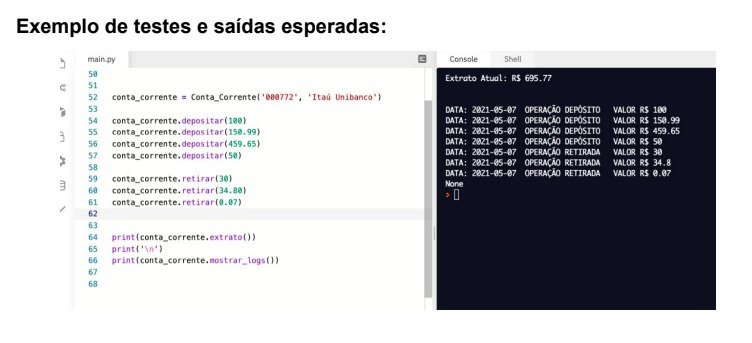

In [ ]:
#Exercício 01:

from datetime import date

class Conta(object):  # criando class chamada conta
  def __init__(self, numero, banco):    # Metódo = "Função"
    self.__numero = numero     #Objeto = "variável"
    self.__banco = banco       # self restringir somente leitura

  #Atributo privado acesso a leitura numero
  @property # encapsulamento = proteger uma parte do seu código
  def numero(self):
    return self.__numero

  #Atributo privado acesso a escrita numero
  @numero.setter # seder o atributo privado para ler essa variavel e escrever nessa váriavel
  def numero(self, numero):
    self.__numero = numero

  #Atributo privado acesso a leitura banco
  @property
  def banco(self):
    return self.__banco

  #Atributo privado acesso a escrita banco
  @numero.setter
  def banco(self, banco):
    self.__banco = banco

  #Metodo mostrar os dados
  def mostrar_dados(self):
    return f'Conta Número {self.__numero} - Banco {self.__banco}'

class Conta_Corrente(Conta):
  def __init__(self, numero, banco):
    super().__init__(numero, banco)  # Super: class filha herdar atributos da Class Pai = Conta
    self.__saldo = 0  # __ atributo privado
    self.__logs = []  # __ atributo privado

  def depositar(self, valor):
    self.__saldo += valor    # contador
    self.registrar_novo_log('DEPÓSITO', valor)

  def retirar(self, valor):
    self.__saldo -= valor
    self.registrar_novo_log('RETIRADA', valor)

  def extrato(self):
    return f'Extrato Atual: R$ {self.__saldo}'

  def registrar_novo_log(self, operacao, valor):
    self.__logs.append(
        (str(date.today()), operacao, valor)
        )

  def mostrar_logs(self):
    for l in self.__logs:
      print(f'DATA: {l[0]} OPERACAO {l[1]}   VALOR R$ {l[2]}')


conta_corrente = Conta_Corrente('000772', 'Itaú Unibanco')

conta_corrente.depositar(100)
conta_corrente.depositar(150.99)
conta_corrente.depositar(459.65)
conta_corrente.depositar(50)

conta_corrente.retirar(30)
conta_corrente.retirar(34.80)
conta_corrente.retirar(0.07)

print(conta_corrente.extrato())
print('\n')
print(conta_corrente.mostrar_logs())






Extrato Atual: R$ 695.77


DATA: 2023-11-07 OPERACAO DEPÓSITO   VALOR R$ 100
DATA: 2023-11-07 OPERACAO DEPÓSITO   VALOR R$ 150.99
DATA: 2023-11-07 OPERACAO DEPÓSITO   VALOR R$ 459.65
DATA: 2023-11-07 OPERACAO DEPÓSITO   VALOR R$ 50
DATA: 2023-11-07 OPERACAO RETIRADA   VALOR R$ 30
DATA: 2023-11-07 OPERACAO RETIRADA   VALOR R$ 34.8
DATA: 2023-11-07 OPERACAO RETIRADA   VALOR R$ 0.07
None


2. Considere um arquivo CSV com as informações sobre super heróis:

● id - Número da linha

● name - Nome

● Gender - Gênero

● Eye color - Cor dos olhos

● Race - Raça

● Hair color - Cor do cabelo

● Height - Altura em centímetros

● Publisher - Estúdio

● Skin color - Cor da pele

● Alignment - Vilão ou herói

● Weight - Peso em libras


---


Crie uma função que efetue a leitura do arquivo e crie:

● Um arquivo de saída (.csv) com todos os heróis do gênero masculino (id,
name).

● Um arquivo de saída (.csv) com todos os heróis do gênero feminino (id, name).

● Um arquivo de saída (.csv) com todos os heróis sem gênero definido (id,
name).

● Um arquivo de saída (.txt) com o nome de todos os heróis dos estúdios Marvel
Comics e DC Comics (um nome por linha).

● Um arquivo de saída (.txt) com o nome de todos os heróis que tenham cor de
pele azul e que sejam vilões (uma única linha com os nomes separados por #).

In [22]:
import csv

with open('/content/heroes_information.csv', 'r', encoding='UTF-8') as arquivo:
    hero_csv = csv.DictReader(arquivo, delimiter=',')
    next(hero_csv)
    male = []  # Lista IDs e nomes de heróis masculinos
    female = []  # Lista IDs e nomes de heróis femininos
    unknown = [] # Lista IDs e nomes de heróis indefinidos
    marvel_dc = [] # Lista nomes de heróis Marvel e DC
    villan_blue = [] # Lista nomes de Vilões azuis


    for linha in hero_csv:
        if linha['Gender'] == 'Male':
            male.append((linha['id'], linha['name']))

        elif linha['Gender'] == 'Female':
            female.append((linha['id'], linha['name']))
        else:
          unknown.append((linha['id'], linha['name']))

        if linha['Publisher'] == 'Marvel Comics' or linha['Publisher'] == 'DC Comics':
          marvel_dc.append(linha['name'])

        if linha['Alignment'] == 'bad' and linha['Skin color'] == 'blue':
          villan_blue.append(linha['name'])



'''

    print("Heróis masculinos:")
    for hero in male:
        print(f"ID: {hero[0]}, Nome: {hero[1]}")

    print("\nHeróis femininos:")
    for hero in female:
        print(f"ID: {hero[0]}, Nome: {hero[1]}")

    print("\nHeróis Indefinidos:")
    for hero in indefinido:
        print(f"ID: {hero[0]}, Nome: {hero[1]}")

    print("\nHeróis da Marvel e da DC:")
    for hero in marvel_dc:
        print(f"Nome: {hero}")

    print("\nVilões azuis:")
    for hero in villan_blue:
        print(f"Nome: {hero}")

'''


# Arquivo CSV Heróis Masculino
with open('hero_male.csv', 'w', newline='', encoding='UTF-8') as arquivo:
    writer = csv.writer(arquivo)
    writer.writerow(['id', 'name'])
    writer.writerows(male)

# Arquivo CSV Heróis Feminino
with open('hero_female.csv', 'w', newline='', encoding='UTF-8') as arquivo:
    writer = csv.writer(arquivo)
    writer.writerow(['id', 'name'])
    writer.writerows(female)

# Arquivo CSV Heróis Indefinidos
with open('hero_unknown.csv', 'w', newline='', encoding='UTF-8') as arquivo:
    writer = csv.writer(arquivo)
    writer.writerow(['id', 'name'])
    writer.writerows(unknown)

# Arquivo txt Heróis Marvel e DC
with open('hero_marvel_dc.txt', 'w', encoding='UTF-8') as arquivo:
    arquivo.write('\n'.join(marvel_dc))

# Arquivo txt Vilões Azuis com '#' entre os nomes
with open('villan_blue.txt', 'w', encoding='UTF-8') as arquivo:
    arquivo.write('#'.join(villan_blue))








